In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/healthcare-dataset/healthcare_dataset.csv


## 🏥 Sağlık Verisi Analizi — Aşama 1: Veri Yükleme & İlk Keşif

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Görsel tema ayarları
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('✅ Kütüphaneler yüklendi!')

✅ Kütüphaneler yüklendi!


In [3]:

df = pd.read_csv('/kaggle/input/healthcare-dataset/healthcare_dataset.csv')

print(f'📦 Satır sayısı  : {df.shape[0]:,}')
print(f'📦 Kolon sayısı  : {df.shape[1]}')
print(f'📦 Toplam hücre  : {df.shape[0] * df.shape[1]:,}')

📦 Satır sayısı  : 55,500
📦 Kolon sayısı  : 15
📦 Toplam hücre  : 832,500


In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
missing = df.isnull().sum()
missing

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [7]:
# Sayısal kolonlar
df.describe().round(2)

,Age,Billing Amount,Room Number
count,55500.00,55500.00,55500.00
mean,51.54,25539.32,301.13
std,19.60,14211.45,115.24
min,13.00,-2008.49,101.00
25%,35.00,13241.22,202.00
50%,52.00,25538.07,302.00
75%,68.00,37820.51,401.00
max,89.00,52764.28,500.00


In [8]:
# Kategorik kolonlar
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'\n📌 {col}  →  {df[col].nunique()} benzersiz değer')
    print(df[col].value_counts().head(5))
    print('-' * 40)


📌 Name  →  49992 benzersiz değer
Name
DAvId muNoZ      3
Cody BurNett     2
roDNEy Shaw      2
grEGorY smitH    2
MelisSA coOk     2
Name: count, dtype: int64
----------------------------------------

📌 Gender  →  2 benzersiz değer
Gender
Male      27774
Female    27726
Name: count, dtype: int64
----------------------------------------

📌 Blood Type  →  8 benzersiz değer
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
Name: count, dtype: int64
----------------------------------------

📌 Medical Condition  →  6 benzersiz değer
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Name: count, dtype: int64
----------------------------------------

📌 Date of Admission  →  1827 benzersiz değer
Date of Admission
2024-03-16    50
2022-07-24    49
2020-10-22    49
2021-12-28    48
2021-01-03    48
Name: count, dtype: int64
----------------------------------------

📌 Doctor  →  40341 benzersiz değer
Do

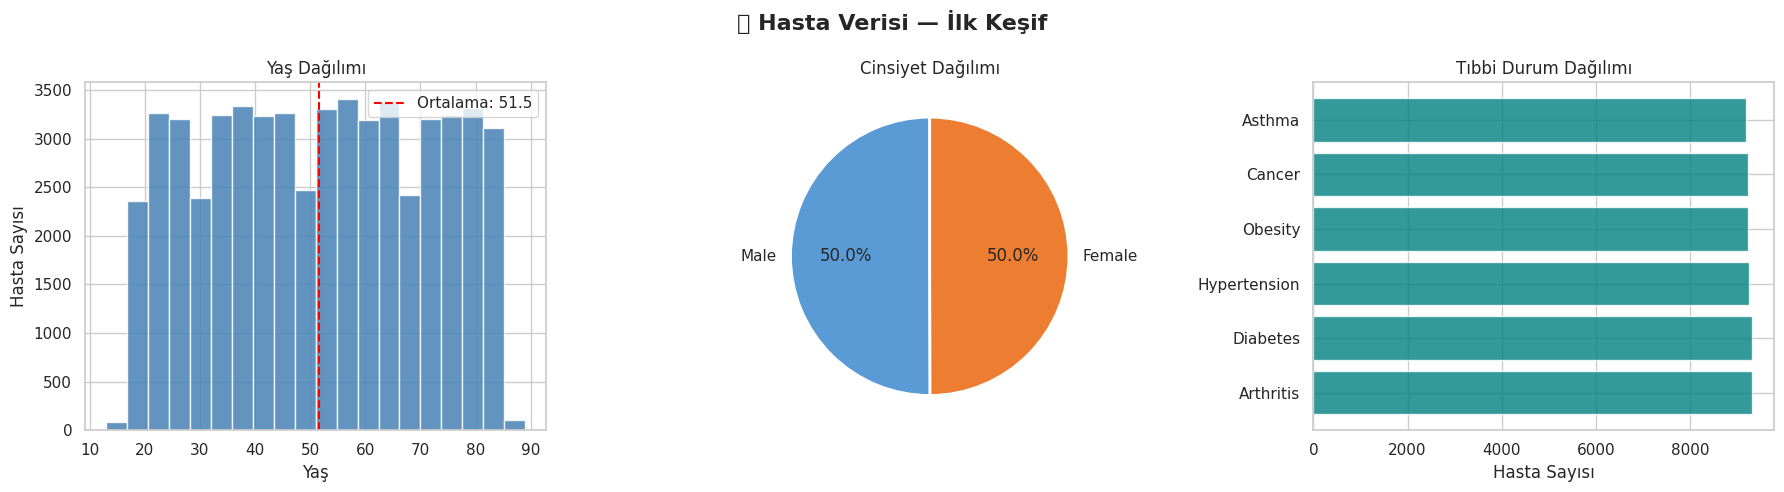

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🏥 Hasta Verisi — İlk Keşif', fontsize=16, fontweight='bold')

# --- Yaş Dağılımı ---
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Yaş Dağılımı')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Hasta Sayısı')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Ortalama: {df['Age'].mean():.1f}")
axes[0].legend()

# --- Cinsiyet Dağılımı ---
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#5B9BD5', '#ED7D31'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Cinsiyet Dağılımı')

# --- Tıbbi Durum Dağılımı ---
condition_counts = df['Medical Condition'].value_counts()
axes[2].barh(condition_counts.index, condition_counts.values, color='teal', alpha=0.8)
axes[2].set_title('Tıbbi Durum Dağılımı')
axes[2].set_xlabel('Hasta Sayısı')

plt.tight_layout()
plt.show()

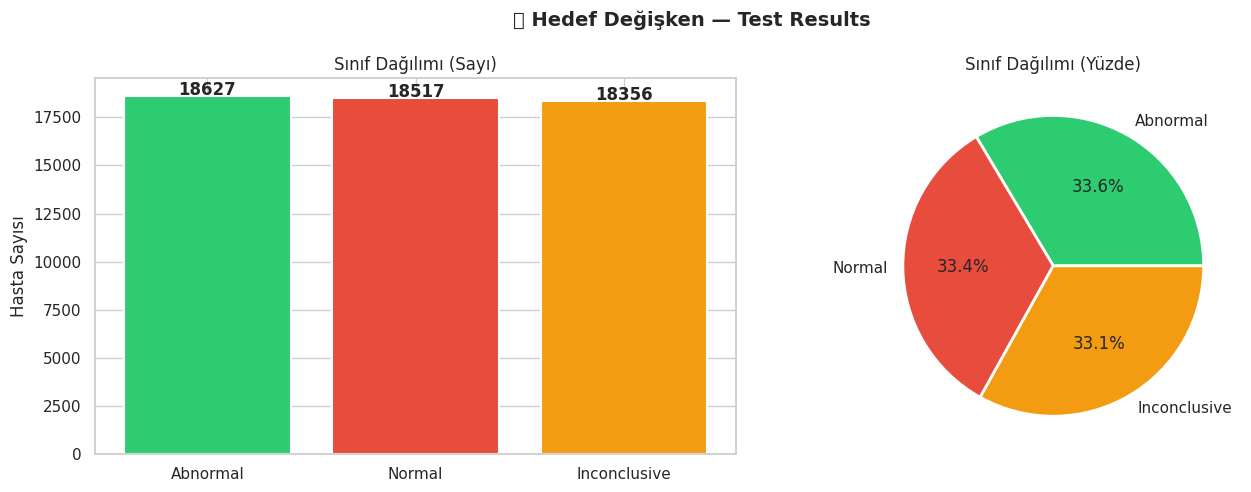


📊 Sınıf dengesizliği var mı?
Test Results
Abnormal        33.6
Normal          33.4
Inconclusive    33.1
Name: proportion, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎯 Hedef Değişken — Test Results', fontsize=14, fontweight='bold')

# Sayısal dağılım
target_counts = df['Test Results'].value_counts()
axes[0].bar(target_counts.index, target_counts.values,
            color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Sınıf Dağılımı (Sayı)')
axes[0].set_ylabel('Hasta Sayısı')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Yüzdesel dağılım
target_pct = df['Test Results'].value_counts(normalize=True) * 100
axes[1].pie(target_pct, labels=target_pct.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#f39c12'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sınıf Dağılımı (Yüzde)')

plt.tight_layout()
plt.show()

print('\n📊 Sınıf dengesizliği var mı?')
print(target_pct.round(1))

 ## Negatif Fatura Anomalisi

In [11]:
negative_bills = df[df['Billing Amount'] < 0]
print(f'⚠️  Negatif fatura sayısı : {len(negative_bills)}')
print(f'📊 Toplam verinin yüzdesi : %{len(negative_bills)/len(df)*100:.2f}')
print(f'💰 Negatif min değer     : {negative_bills["Billing Amount"].min():.2f}')
print()
negative_bills[['Medical Condition', 'Admission Type', 'Billing Amount', 'Test Results']].head()


⚠️  Negatif fatura sayısı : 108
📊 Toplam verinin yüzdesi : %0.19
💰 Negatif min değer     : -2008.49



,Medical Condition,Admission Type,Billing Amount,Test Results
132,Cancer,Urgent,-502.507813,Normal
799,Asthma,Elective,-1018.245371,Inconclusive
1018,Hypertension,Elective,-306.364925,Normal
1421,Asthma,Emergency,-109.097122,Abnormal
2103,Diabetes,Urgent,-576.727907,Abnormal


In [12]:
# Negatif faturaları mutlak değere çevir
df['Billing Amount'] = df['Billing Amount'].abs()

print(f'✅ Düzeltildi!')
print(f'Yeni minimum fatura: ${df["Billing Amount"].min():.2f}')
print(f'Yeni maksimum fatura: ${df["Billing Amount"].max():.2f}')

✅ Düzeltildi!
Yeni minimum fatura: $9.24
Yeni maksimum fatura: $52764.28


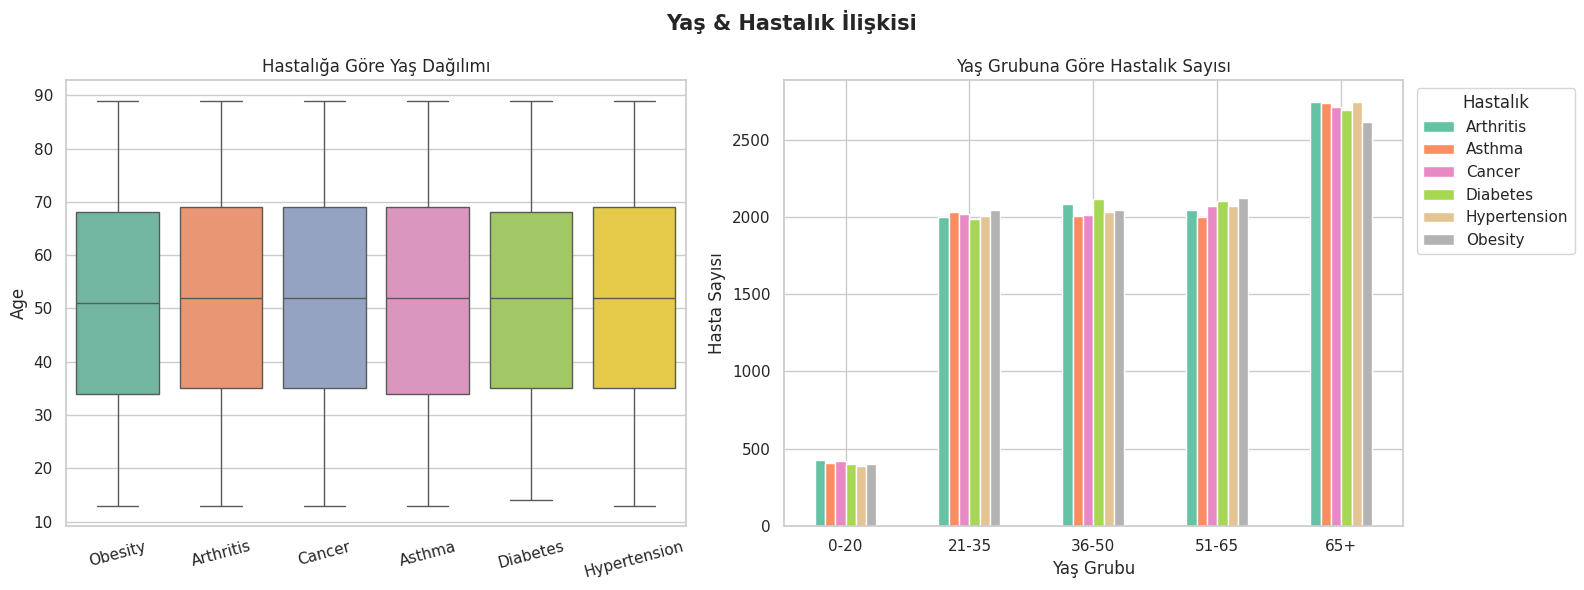

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Yaş & Hastalık İlişkisi', fontsize=15, fontweight='bold')

# Boxplot — hastalığa göre yaş dağılımı
order = df.groupby('Medical Condition')['Age'].median().sort_values().index
sns.boxplot(data=df, x='Medical Condition', y='Age', order=order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Hastalığa Göre Yaş Dağılımı')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Yaş grubu oluştur
df['Age Group'] = pd.cut(df['Age'],
                         bins=[0, 20, 35, 50, 65, 100],
                         labels=['0-20', '21-35', '36-50', '51-65', '65+'])

age_condition = df.groupby(['Age Group', 'Medical Condition'], observed=True).size().unstack()
age_condition.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Yaş Grubuna Göre Hastalık Sayısı')
axes[1].set_xlabel('Yaş Grubu')
axes[1].set_ylabel('Hasta Sayısı')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Hastalık', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
import matplotlib.ticker as mticker
print('✅ mticker yüklendi!')

✅ mticker yüklendi!


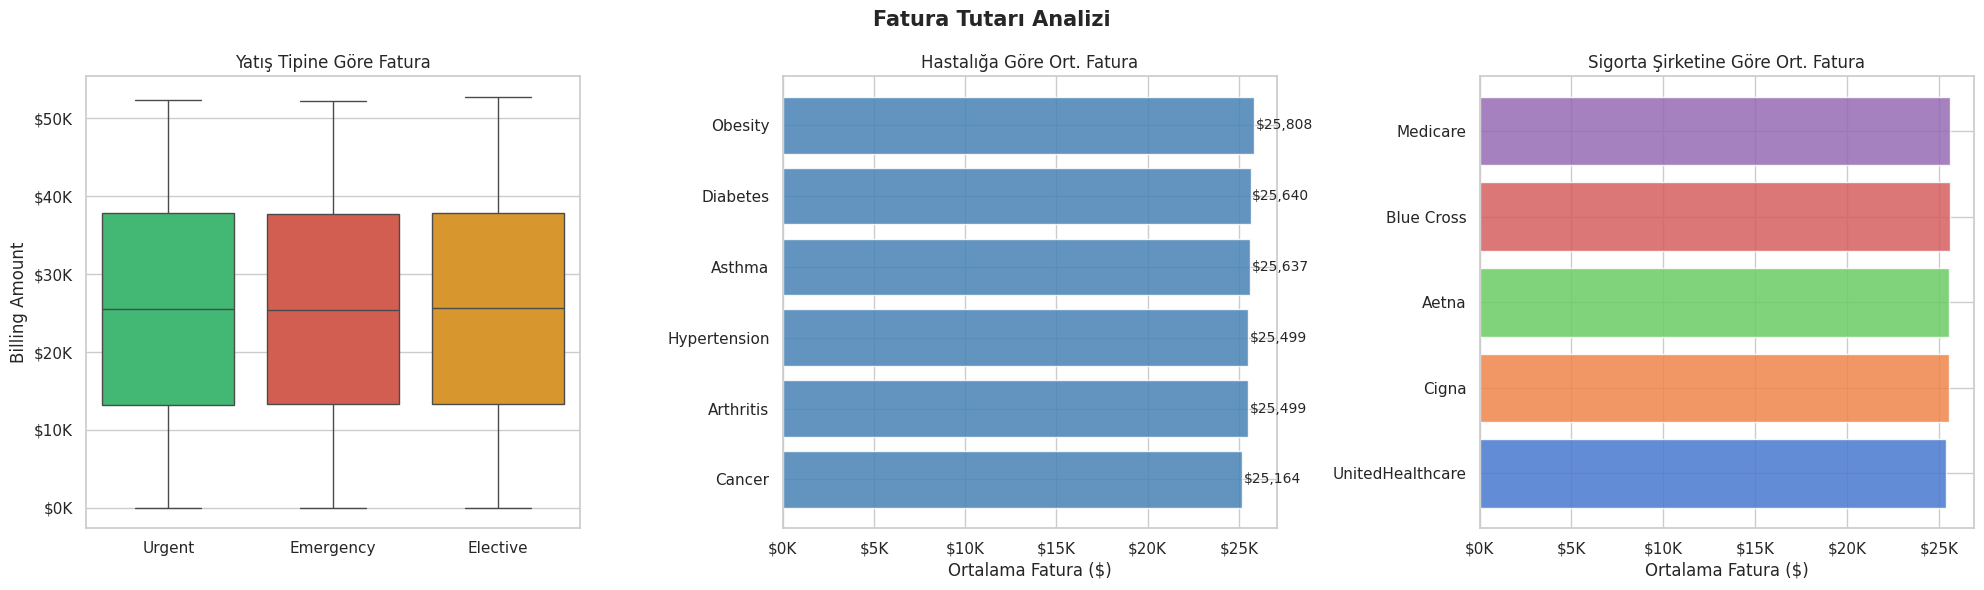

In [16]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Fatura Tutarı Analizi', fontsize=15, fontweight='bold')

# Yatış tipine göre fatura
sns.boxplot(data=df, x='Admission Type', y='Billing Amount',
            palette=['#2ecc71', '#e74c3c', '#f39c12'], ax=axes[0])
axes[0].set_title('Yatış Tipine Göre Fatura')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Hastalığa göre ortalama fatura
avg_billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=True)
axes[1].barh(avg_billing.index, avg_billing.values, color='steelblue', alpha=0.85)
axes[1].set_title('Hastalığa Göre Ort. Fatura')
axes[1].set_xlabel('Ortalama Fatura ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for i, v in enumerate(avg_billing.values):
    axes[1].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=10)

# Sigorta şirketine göre ortalama fatura
avg_ins = df.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=True)
colors = sns.color_palette('muted', len(avg_ins))
axes[2].barh(avg_ins.index, avg_ins.values, color=colors, alpha=0.85)
axes[2].set_title('Sigorta Şirketine Göre Ort. Fatura')
axes[2].set_xlabel('Ortalama Fatura ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

In [25]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

print(df['Length of Stay'].describe().round(1))

count    55500.0
mean        15.5
std          8.7
min          1.0
25%          8.0
50%         15.0
75%         23.0
max         30.0
Name: Length of Stay, dtype: float64


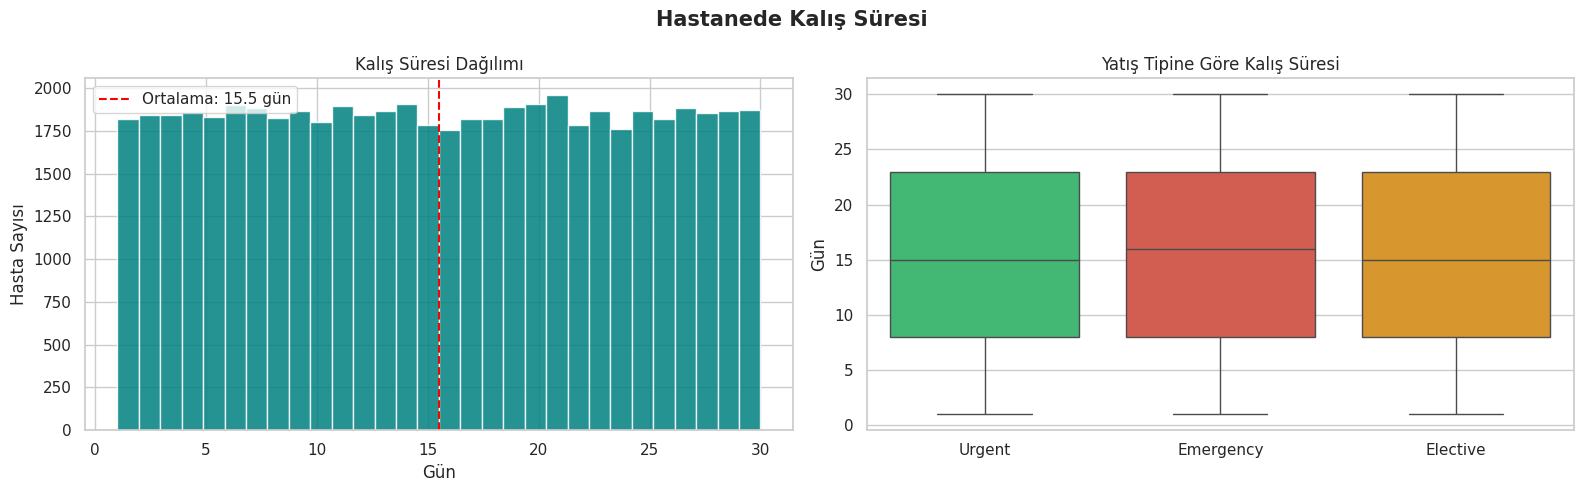

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Hastanede Kalış Süresi', fontsize=15, fontweight='bold')

# Genel dağılım
axes[0].hist(df['Length of Stay'], bins=30, color='teal', edgecolor='white', alpha=0.85)
axes[0].set_title('Kalış Süresi Dağılımı')
axes[0].set_xlabel('Gün')
axes[0].set_ylabel('Hasta Sayısı')
axes[0].axvline(df['Length of Stay'].mean(), color='red', linestyle='--',
                label=f"Ortalama: {df['Length of Stay'].mean():.1f} gün")
axes[0].legend()

# Yatış tipine göre kalış süresi
sns.boxplot(data=df, x='Admission Type', y='Length of Stay',
            palette=['#2ecc71', '#e74c3c', '#f39c12'], ax=axes[1])
axes[1].set_title('Yatış Tipine Göre Kalış Süresi')
axes[1].set_xlabel('')
axes[1].set_ylabel('Gün')

plt.tight_layout()
plt.show()

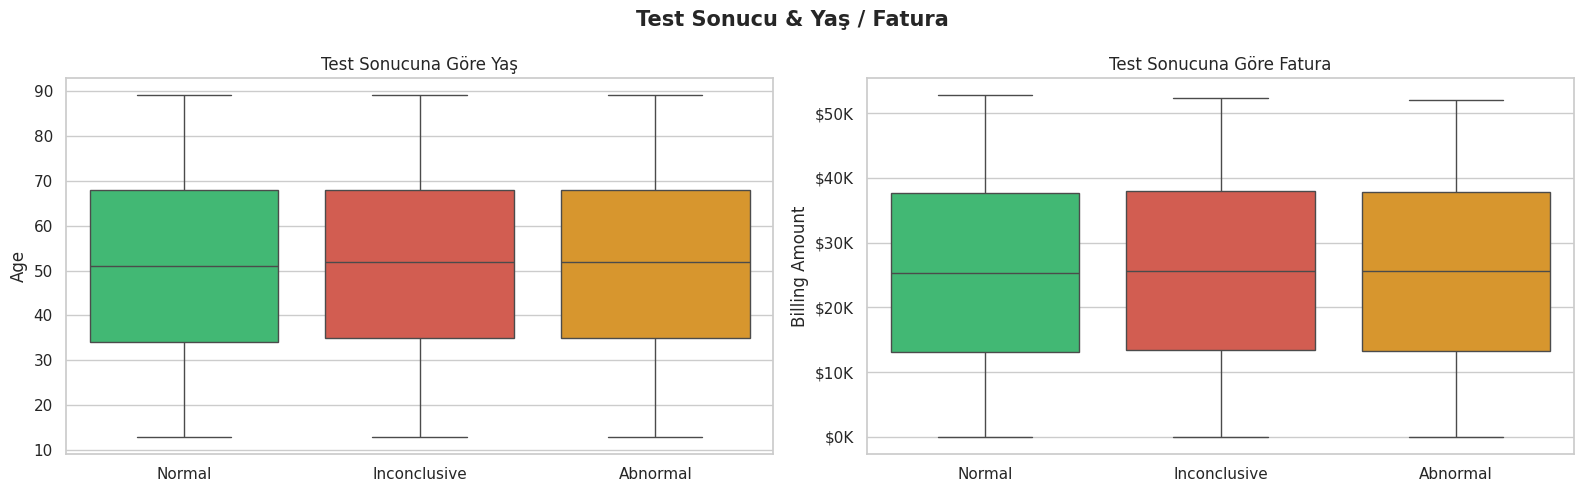

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Test Sonucu & Yaş / Fatura', fontsize=15, fontweight='bold')

sns.boxplot(data=df, x='Test Results', y='Age',
            palette=['#2ecc71', '#e74c3c', '#f39c12'], ax=axes[0])
axes[0].set_title('Test Sonucuna Göre Yaş')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='Test Results', y='Billing Amount',
            palette=['#2ecc71', '#e74c3c', '#f39c12'], ax=axes[1])
axes[1].set_title('Test Sonucuna Göre Fatura')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

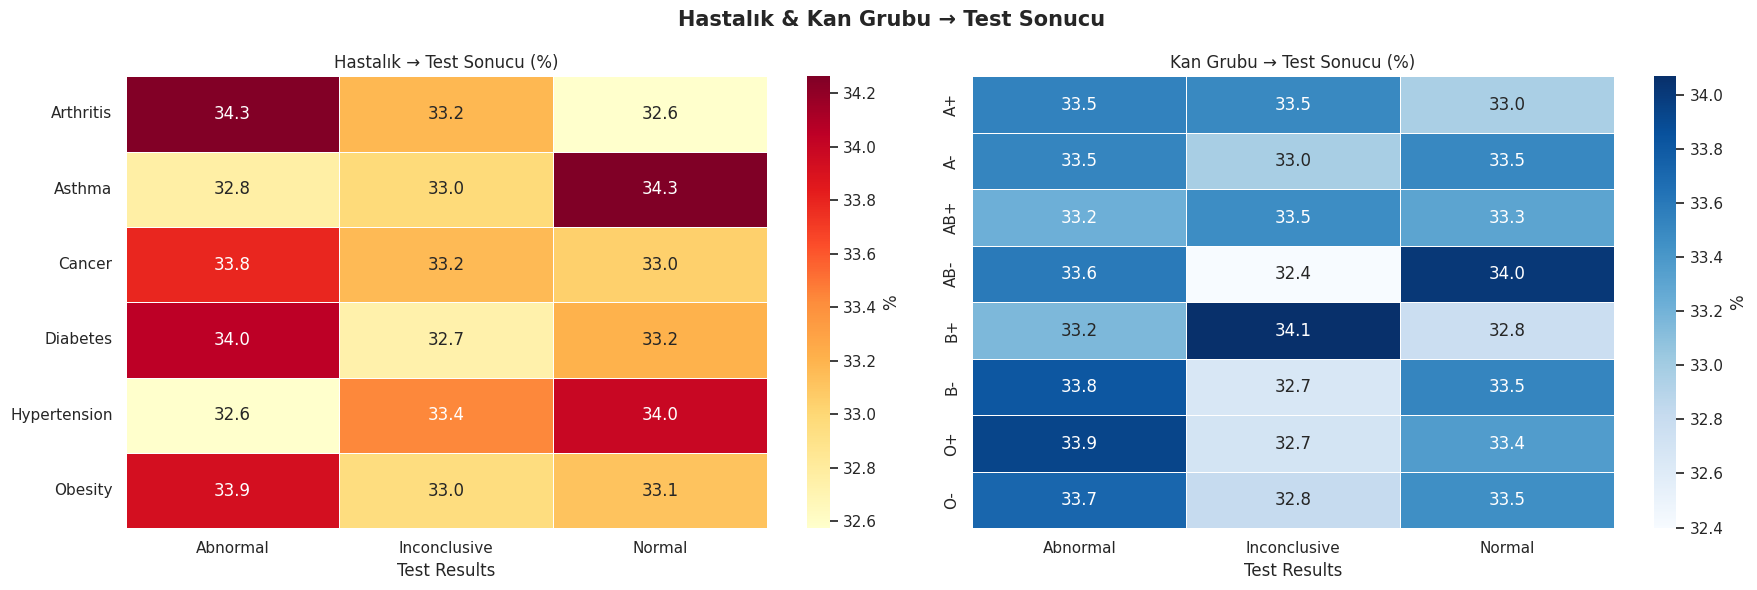

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Hastalık & Kan Grubu → Test Sonucu', fontsize=15, fontweight='bold')

ct = pd.crosstab(df['Medical Condition'], df['Test Results'], normalize='index') * 100
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '%'})
axes[0].set_title('Hastalık → Test Sonucu (%)')
axes[0].set_ylabel('')

ct2 = pd.crosstab(df['Blood Type'], df['Test Results'], normalize='index') * 100
sns.heatmap(ct2, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('Kan Grubu → Test Sonucu (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

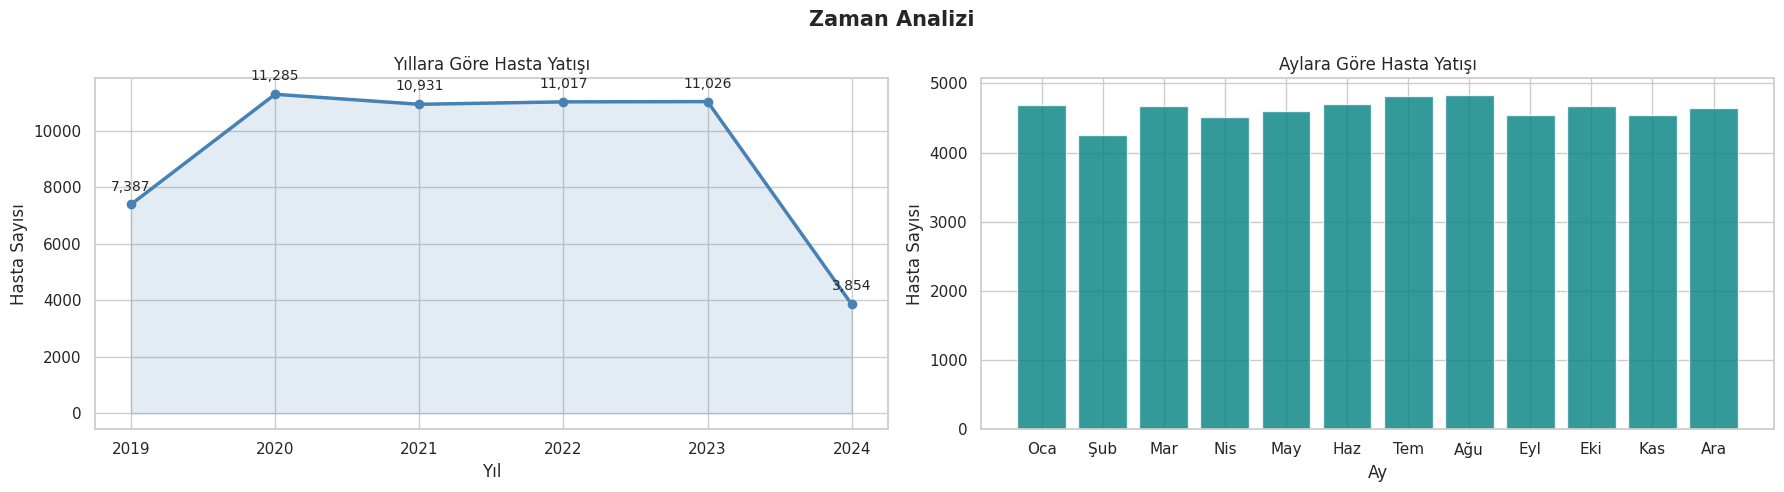

In [29]:
df['Admission Year']  = df['Date of Admission'].dt.year
df['Admission Month'] = df['Date of Admission'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Zaman Analizi', fontsize=15, fontweight='bold')

yearly = df.groupby('Admission Year').size()
axes[0].plot(yearly.index, yearly.values, marker='o', color='steelblue', linewidth=2.5)
axes[0].fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
axes[0].set_title('Yıllara Göre Hasta Yatışı')
axes[0].set_xlabel('Yıl')
axes[0].set_ylabel('Hasta Sayısı')
for x, y in zip(yearly.index, yearly.values):
    axes[0].annotate(f'{y:,}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=10)

monthly = df.groupby('Admission Month').size()
month_names = ['Oca','Şub','Mar','Nis','May','Haz','Tem','Ağu','Eyl','Eki','Kas','Ara']
axes[1].bar(month_names, monthly.values, color='teal', alpha=0.8, edgecolor='white')
axes[1].set_title('Aylara Göre Hasta Yatışı')
axes[1].set_xlabel('Ay')
axes[1].set_ylabel('Hasta Sayısı')

plt.tight_layout()
plt.show()

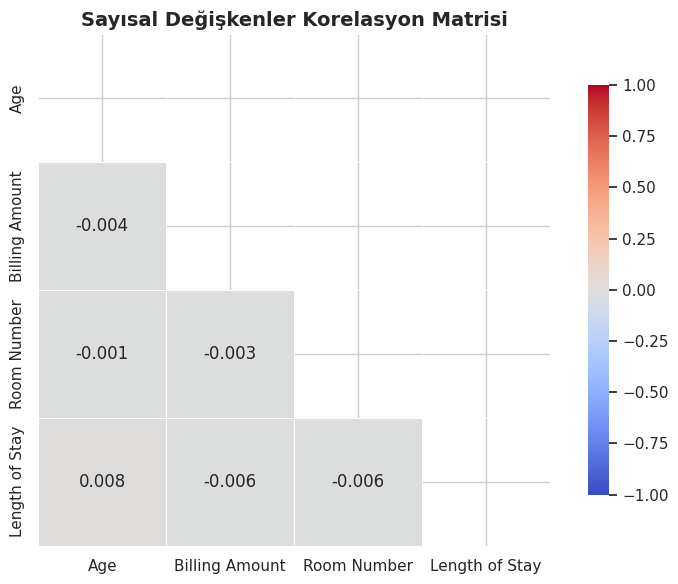

In [30]:
numeric_cols = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Sayısal Değişkenler Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
drop_cols = ['Name', 'Doctor', 'Hospital', 'Date of Admission', 'Discharge Date']
df_model = df.drop(columns=drop_cols)

print(f'Kalan kolon sayısı: {df_model.shape[1]}')
print(df_model.columns.tolist())

Kalan kolon sayısı: 14
['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Medication', 'Test Results', 'Age Group', 'Length of Stay', 'Admission Year', 'Admission Month']


In [32]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Gender', 'Blood Type', 'Medical Condition',
                    'Insurance Provider', 'Admission Type', 'Medication', 'Age Group']

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('✅ Encoding tamamlandı!')
print(df_model.head())

✅ Encoding tamamlandı!
   Age  Gender  Blood Type  Medical Condition  Insurance Provider  \
0   30       1           5                  2                   1   
1   62       1           0                  5                   3   
2   76       0           1                  5                   0   
3   28       0           6                  3                   3   
4   43       0           2                  2                   0   

   Billing Amount  Room Number  Admission Type  Medication  Test Results  \
0    18856.281306          328               2           3        Normal   
1    33643.327287          265               1           1  Inconclusive   
2    27955.096079          205               1           0        Normal   
3    37909.782410          450               0           1      Abnormal   
4    14238.317814          458               2           4      Abnormal   

   Age Group  Length of Stay  Admission Year  Admission Month  
0          1               2            2

In [33]:
X = df_model.drop(columns=['Test Results'])
y = le.fit_transform(df_model['Test Results'])

print(f'X boyutu : {X.shape}')
print(f'y boyutu : {y.shape}')
print(f'Sınıflar : {le.classes_}')

X boyutu : (55500, 13)
y boyutu : (55500,)
Sınıflar : ['Abnormal' 'Inconclusive' 'Normal']


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Eğitim seti : {X_train.shape[0]:,} satır')
print(f'Test seti   : {X_test.shape[0]:,} satır')

Eğitim seti : 44,400 satır
Test seti   : 11,100 satır


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('✅ Ölçeklendirme tamamlandı!')

✅ Ölçeklendirme tamamlandı!


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('🌲 Random Forest Sonuçları:')
print(classification_report(y_test, y_pred_rf,
      target_names=['Abnormal', 'Inconclusive', 'Normal']))

🌲 Random Forest Sonuçları:
              precision    recall  f1-score   support

    Abnormal       0.44      0.46      0.45      3726
Inconclusive       0.44      0.44      0.44      3671
      Normal       0.45      0.43      0.44      3703

    accuracy                           0.44     11100
   macro avg       0.44      0.44      0.44     11100
weighted avg       0.44      0.44      0.44     11100



In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('⚡ XGBoost Sonuçları:')
print(classification_report(y_test, y_pred_xgb,
      target_names=['Abnormal', 'Inconclusive', 'Normal']))

⚡ XGBoost Sonuçları:
              precision    recall  f1-score   support

    Abnormal       0.37      0.39      0.38      3726
Inconclusive       0.37      0.37      0.37      3671
      Normal       0.38      0.36      0.37      3703

    accuracy                           0.38     11100
   macro avg       0.38      0.38      0.38     11100
weighted avg       0.38      0.38      0.38     11100



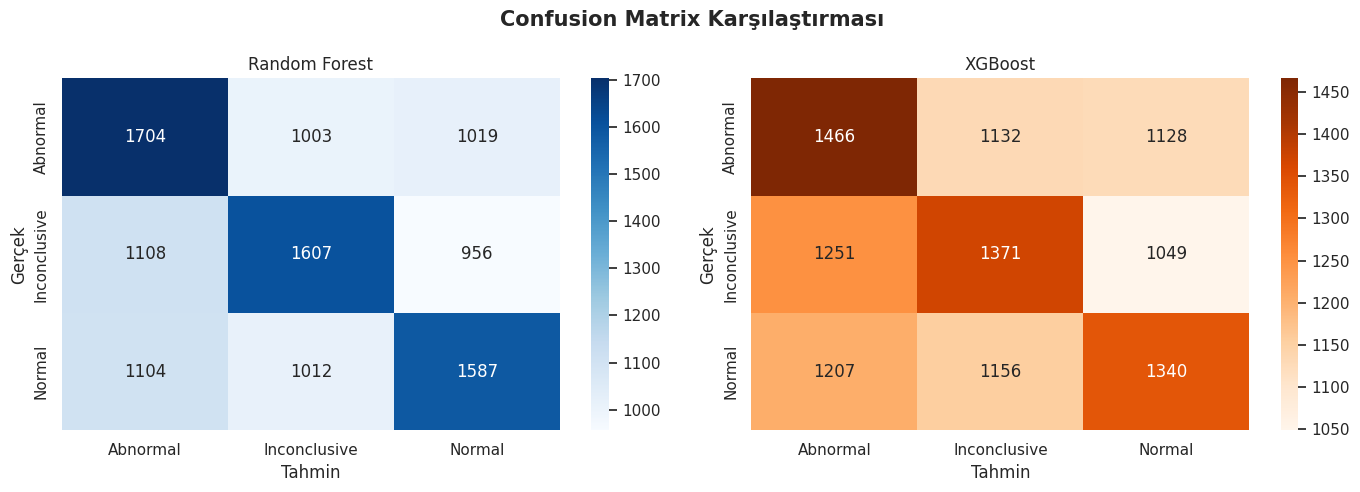

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix Karşılaştırması', fontsize=15, fontweight='bold')

labels = ['Abnormal', 'Inconclusive', 'Normal']

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Random Forest')
axes[0].set_ylabel('Gerçek')
axes[0].set_xlabel('Tahmin')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d',
            cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('XGBoost')
axes[1].set_ylabel('Gerçek')
axes[1].set_xlabel('Tahmin')

plt.tight_layout()
plt.show()

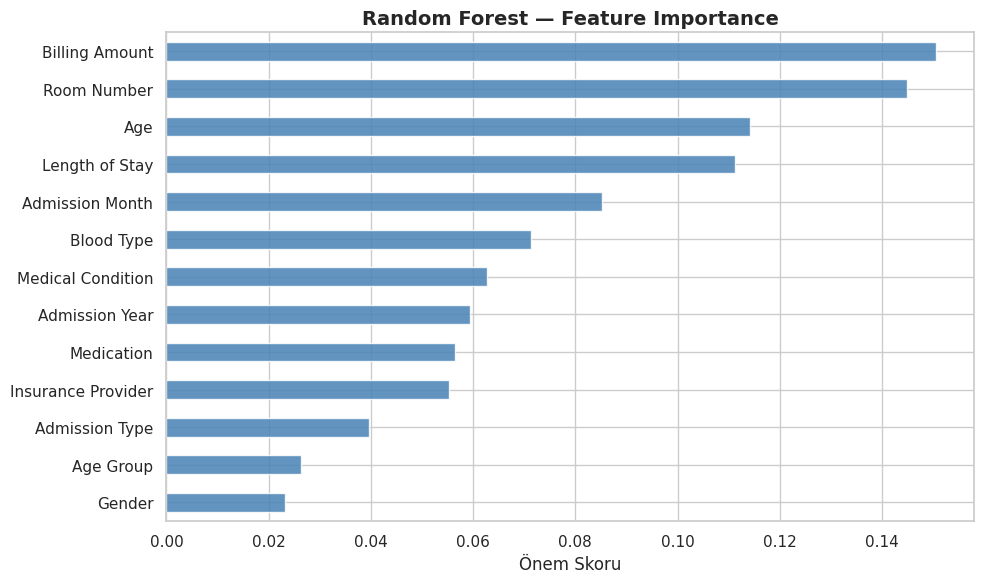

In [39]:
feature_names = df_model.drop(columns=['Test Results']).columns

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', alpha=0.85)
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

        Model  Accuracy
Random Forest     44.13
      XGBoost     37.63


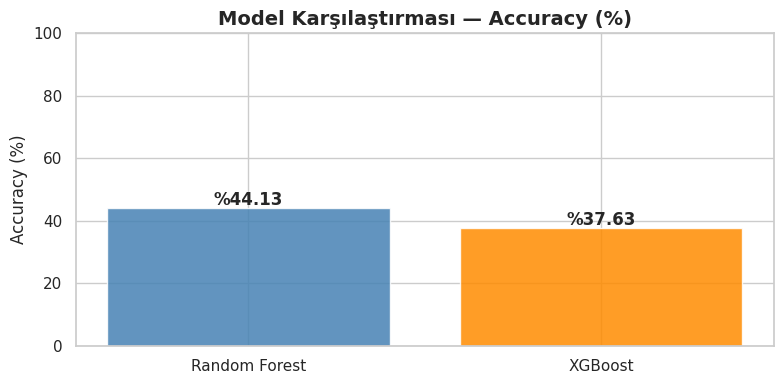

In [40]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results['Accuracy'] = (results['Accuracy'] * 100).round(2)
print(results.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(results['Model'], results['Accuracy'],
        color=['steelblue', 'darkorange'], alpha=0.85, edgecolor='white')
plt.title('Model Karşılaştırması — Accuracy (%)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 1, f'%{v}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()